# Titanic Survival Predictions

## 1. Imports and Dataset **Loading**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [24]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Inspecting Dataset


In [25]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [26]:
# we use survival related columns
# Name, Ticket, Cabin, and PassengerId are dropped
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

X = df[features]
y = df["Survived"]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## 3. Handling Missing Values and Encoding

In [27]:
X = X.copy()

X["Age"] = X["Age"].fillna(X["Age"].median())
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

X.isnull().sum()
# To fill the missing data
#  Age is handled with median age
# Embarked is handled with most common port used

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [28]:
# We then convert categorical columns into numbers to encode the data
X = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True)

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## 4. Train/Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((712, 8), (179, 8))

## 5. Building Decision Tree

In [30]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

## 6. Prediction

In [31]:
y_pred = tree_model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0])

## 7. Evaluation

In [32]:
accuracy = accuracy_score(y_test, y_pred)
accuracy


0.7877094972067039

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.94      0.84       110
           1       0.84      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.76       179
weighted avg       0.80      0.79      0.78       179



In [34]:
confusion_matrix(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Died", "Actual Survived"],
    columns=["Predicted Died", "Predicted Survived"]
)

cm_df

,Predicted Died,Predicted Survived
Actual Died,103,7
Actual Survived,31,38


## 8. Visualization

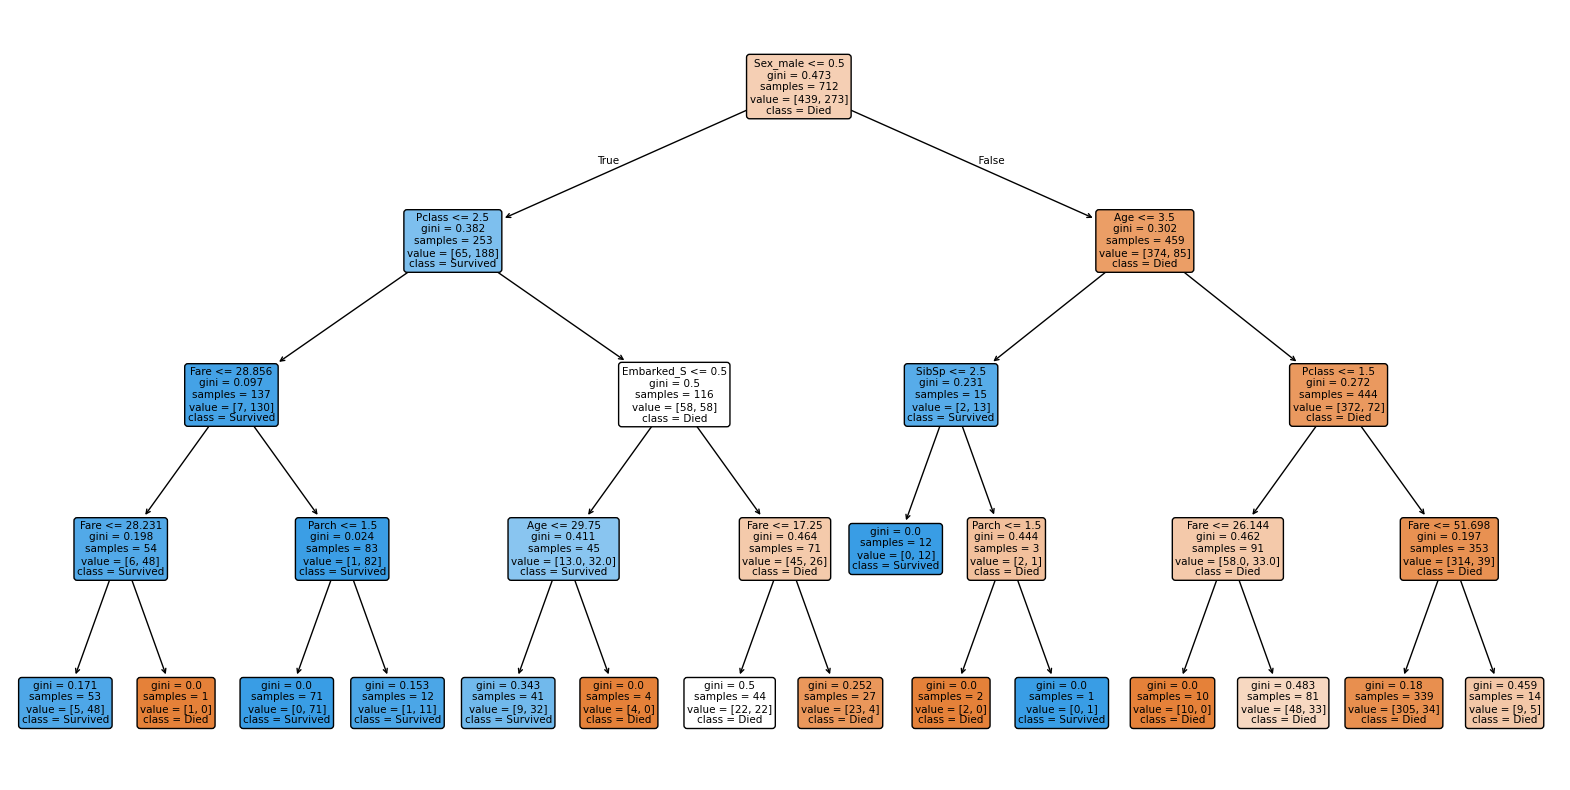

In [35]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True
)

plt.show()

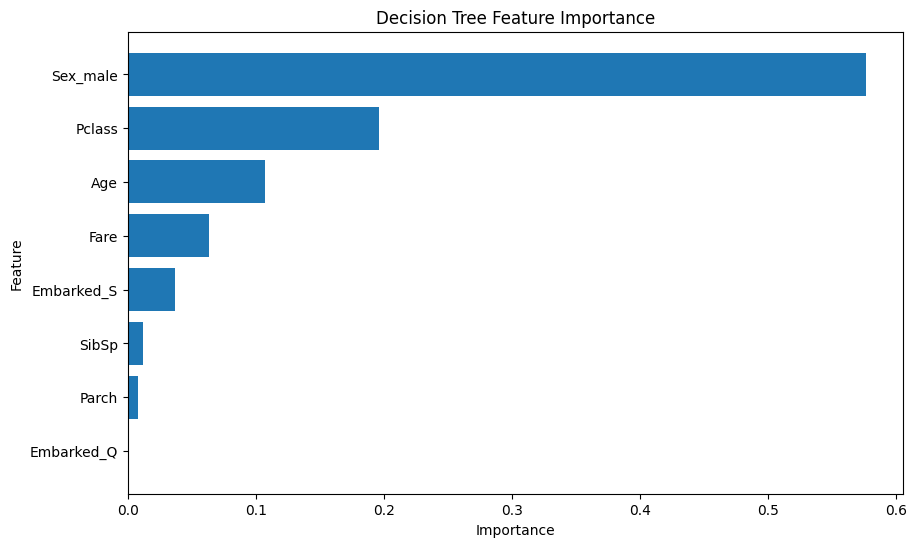

In [36]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})

importances = importances.sort_values(by="Importance", ascending=False)

importances
plt.figure(figsize=(10, 6))

plt.barh(importances["Feature"], importances["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()

plt.show()

## 9. Training vs Testing Accuracy

In [37]:
sample_passenger = X.iloc[[0]]

prediction = tree_model.predict(sample_passenger)

prediction

array([0])

In [38]:
if prediction[0] == 1:
    print("Predicted: Survived")
else:
    print("Predicted: Did not survive")

Predicted: Did not survive


In [39]:
train_accuracy = tree_model.score(X_train, y_train)
test_accuracy = tree_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8412921348314607
Testing Accuracy: 0.7877094972067039


## Conclusion

The model achieved a training accuracy of about 84.1% and a testing accuracy of about 78.8%. This shows that the model performed fairly well on unseen data, with only slight overfitting.